In [3]:
import numpy as np
from scipy.stats import norm

In [18]:
# Define baseline functions & constants
BUDGET_SIZE = 50000
WORST_SPEED_MULT = 0.1
def research(invested: int) -> float:
    return 200000 * np.log(1 + invested) / np.log(1+100)
def scale(invested: int) -> float:
    return (invested*7)/100
def probability_fn(s):
    p_troll = 0.05
    p_low = 0.4
    p_mid = 0.32
    p_high=0.23
    return (
        p_troll * norm.cdf(s, 95, 3) + 
        p_low * norm.cdf(s, 8, 4) +
        p_mid * norm.cdf(s, 40, 10) +
        p_high * norm.cdf(s, 85, 8)
    )

def speed(invested:int) -> float: # Wild card
    if invested==0:
        return WORST_SPEED_MULT
    ans = 0.1 + 0.8*probability_fn(invested)
    return max(WORST_SPEED_MULT, ans)

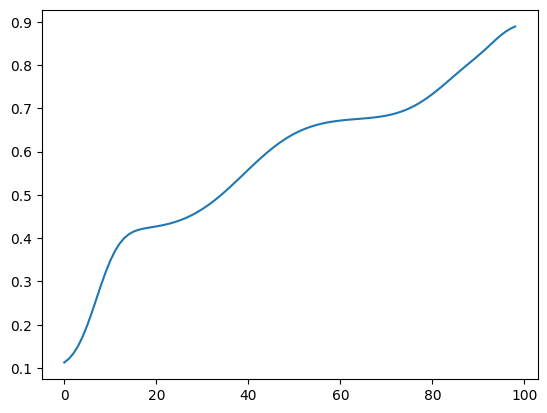

In [19]:
# Graph probability function
import matplotlib.pyplot as plt
y_val = []
for i in range(1,100):
    y_val.append(speed(i))

plt.plot(y_val)
plt.show()

In [24]:
speed(15)

np.float64(0.4087707441269772)

In [21]:
# Brute force best scenario while investing NOTHING in speed
best_answer = (1,1)
best_payoff = 0
for research_invested in range(1, 100):
    scale_left = 100 - research_invested
    for scale_invested in range(1, scale_left+1):
        research_cost = (research_invested/100) * BUDGET_SIZE
        scale_cost = (scale_invested/100) * BUDGET_SIZE
        budget_used = research_cost+scale_cost
        payoff = (research(research_invested) * scale(scale_invested) * speed(0)) - budget_used
        if payoff > best_payoff:
            best_answer = (research_invested, scale_invested)
            best_payoff = payoff

print("Best Answer: " + str(best_answer))
print("Best Payoff: " + str(best_payoff)) 

Best Answer: (23, 77)
Best Payoff: 24232.991676237158


In [22]:
# Brute force best scenario, assuming speed assumptions
best_answer = (1,1,1)
best_payoff = 0
heat_map = []
for research_invested in range(1, 100):
    scale_left = 100 - research_invested
    mp_row = [0 for i in range(1, 100)]
    for scale_invested in range(1, scale_left+1):
        speed_left = 100 - research_invested - scale_invested
        for speed_invested in range(1, speed_left+1):
            research_cost = (research_invested/100) * BUDGET_SIZE
            scale_cost = (scale_invested/100) * BUDGET_SIZE
            speed_cost = (speed_invested/100) * BUDGET_SIZE
            budget_used = research_cost+scale_cost+speed_cost
            payoff = (research(research_invested) * scale(scale_invested) * speed(speed_invested)) - budget_used
            if speed_invested==speed_left:
                mp_row[scale_invested] = payoff
            if payoff > best_payoff:
                best_answer = (research_invested, scale_invested,speed_invested)
                best_payoff = payoff
    heat_map.append(mp_row)

print("Best Answer: " + str(best_answer))
print("Best Payoff: " + str(best_payoff)) 

Best Answer: (20, 65, 15)
Best Payoff: 195390.26554835297


In [8]:
!pip install seaborn


Text(0.5, 1.0, 'Payoff Heatmap (based on player type assumptions)')

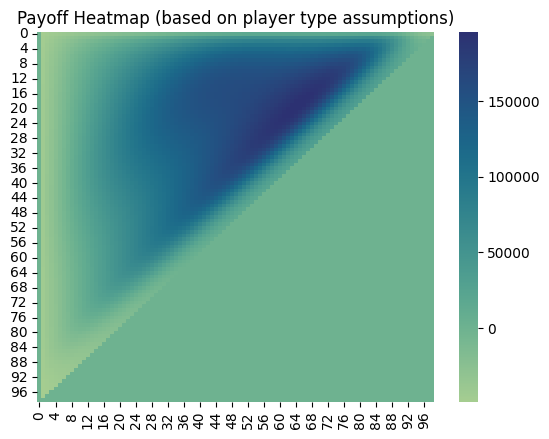

In [23]:
import seaborn as sns 
sns.heatmap(heat_map, cmap="crest").set_title("Payoff Heatmap (based on player type assumptions)")